# `jlegroup.EY92` — the analytic small-planet model

**Elliot & Young 1992**, AJ 103, 991 — *"Analysis of Stellar Occultation Data for Planetary Atmospheres. I. Model Fitting, with Application to Pluto"*.

EY92 writes the occultation light curve of a **small planet** — one whose scale height is not negligible against its radius — as asymptotic series in $1/\lambda$, the ratio of gravitational potential energy to $kT$. The atmosphere is a power-law family ($T \propto r^b$, $\mu \propto r^{-a}$, hydrostatic) with an optional haze-absorption layer. Because evaluation is analytic (no numerical integration), EY92 is the natural **fitting model**, and it supplies the boundary condition for the EPQ03 inversion.

`EY92.ElliotYoung1992Model` is deliberately drop-in comparable with `CE97.ChamberlainElliot1997Model`: physical parameters in, `main()`, then read `focusedFlux` and friends.

**Two things to know before fitting** (details in §3):
- `seriesOrder` defaults to **4** (most accurate). The Mathematica jleGroup default is **1** — pass `seriesOrder=1` to reproduce group reference curves.
- The published EY92 appendix carries two misprints (in Eqs. A2 and A6); the module corrects them by default (`seriesVariant="corrected"`), and `"as-printed"` reproduces the journal text.

Companions: [overview](00_jlegroup_overview.ipynb) · [CE97](02_CE97_basics.ipynb) · [EPQ03](03_EPQ03_basics.ipynb)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import jlegroup
from jlegroup import EY92, physicalData

print("jlegroup", jlegroup.__version__)

jlegroup 0.7.0


## 1. A Triton-like isothermal occultation

Physical inputs are reference conditions at one radius plus the body. We use the package's benchmark body — Triton's mass, straight from the `physicalData.BODIES` registry — with a 114.5 K N₂ atmosphere referenced at 1200 km, observed from 30 AU. The model converts these to the EY92 parameters
$\lambda_{g0} = GM\mu/(R\,T_0\,r_0)$ [Eq. 3.10] and the reference refractivity $\nu_0$ [Eqs. 3.15, 3.19], using `physicalData` conventions throughout.

In [2]:
triton = physicalData.BODIES["Triton"]
D_KM = 30 * physicalData.AU_KM

common = dict(
    referencePressure=17.18,      # Pa at the reference radius (= 171.8 microbar)
    referenceTemperature=114.5,   # K
    referenceRadius=1200.0,       # km
    planetMass=triton.mass_kg,
    meanMolecularMass=physicalData.MOLAR_MASS["N2"],
    planetDistance=D_KM,
)

y = np.arange(800.0, 2301.0, 1.0)             # shadow radii, km
iso = EY92.ElliotYoung1992Model(**common, position=y)
flux = iso.main()

print(f"lambda_g0 = {iso.lambda_g0:.2f}   nu0 = {iso.nu0:.3e}")
print(f"scale height at r0: H = r0/lambda_g0 = {1200/iso.lambda_g0:.1f} km")

lambda_g0 = 35.01   nu0 = 1.201e-07
scale height at r0: H = r0/lambda_g0 = 34.3 km


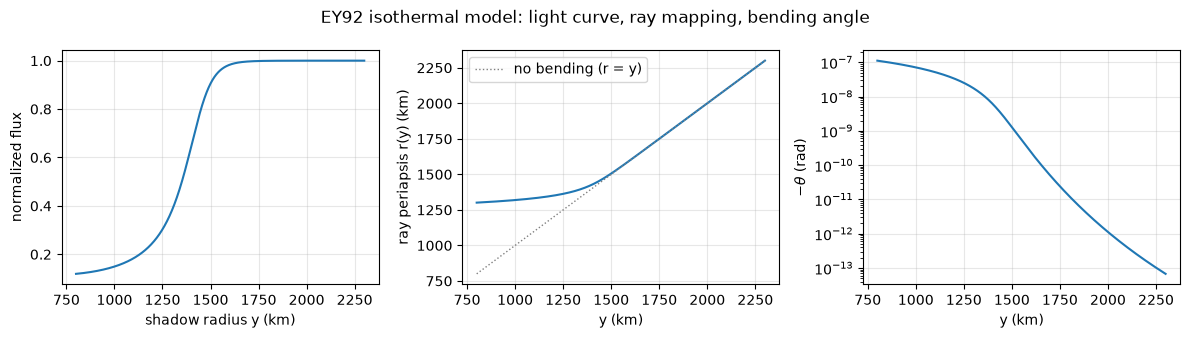

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3.4))
ax[0].plot(y, flux)
ax[0].set_xlabel("shadow radius y (km)"); ax[0].set_ylabel("normalized flux")
ax[1].plot(y, iso.planetRadius_solution)
ax[1].plot(y, y, ":", color="gray", lw=1, label="no bending (r = y)")
ax[1].set_xlabel("y (km)"); ax[1].set_ylabel("ray periapsis r(y) (km)"); ax[1].legend()
ax[2].semilogy(y, -iso.theta)
ax[2].set_xlabel("y (km)"); ax[2].set_ylabel(r"$-\theta$ (rad)")
for a in ax: a.grid(alpha=0.3)
fig.suptitle("EY92 isothermal model: light curve, ray mapping, bending angle")
fig.tight_layout()

## 2. Chords in time, and thermal gradients

An observed chord has $y(t) = \sqrt{\rho_{\min}^2 + (v\,t)^2}$. The `temperatureExponent` argument is EY92's $b$ ($T \propto r^b$): more negative $b$ means a colder, more compact upper atmosphere and a steeper drop. (Steep gradients also amplify the series-truncation error — see §3.)

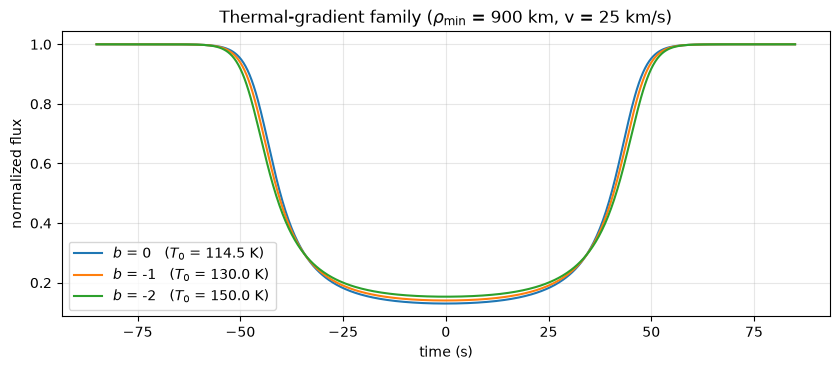

In [4]:
rho_min, v = 900.0, 25.0
t = np.arange(-85.0, 85.001, 0.25)
y_t = np.sqrt(rho_min**2 + (v * t) ** 2)

plt.figure(figsize=(8.5, 3.8))
for b, t_ref in [(0.0, 114.5), (-1.0, 130.0), (-2.0, 150.0)]:
    m = EY92.ElliotYoung1992Model(**{**common, "referenceTemperature": t_ref},
                                  position=y_t, temperatureExponent=b)
    plt.plot(t, m.main(), label=f"$b$ = {b:g}   ($T_0$ = {t_ref} K)")
plt.xlabel("time (s)"); plt.ylabel("normalized flux")
plt.title(rf"Thermal-gradient family ($\rho_{{\rm min}}$ = {rho_min:.0f} km, v = {v:.0f} km/s)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()

## 3. Series order, and the appendix misprints

The flux series is truncated at `seriesOrder` (0–4):

- **0** — the Baum & Code (1953) large-planet limit;
- **1** — the Mathematica jleGroup default (`olcEYorderForOneOverLambda = 1`): use it to reproduce group reference curves;
- **4** — this module's default.

For this isothermal $\lambda_{g0} \approx 35$ atmosphere the order-1 truncation sits at the few-$\times 10^{-5}$ level. The neglected next term's coefficient, $(9 - 34b + 25b^2)/128$, grows steeply with thermal gradient — at $b = -4.5$ it reaches 5.2 and the truncation costs $\sim 10^{-3}$ (that is the documented residual of the package's steep-clear benchmark).

The misprints: the printed appendix has a wrong denominator in A2's $\delta^4 b^3$ term (8192 → should be 32768) and a wrong coefficient in A6's $\delta^4 b^2$ term (10555 → should be 1055, the error inherited by Chamberlain 1996). `seriesVariant="corrected"` (default) fixes both. Note both misprinted terms carry powers of $b$ — they are invisible on isothermal atmospheres, so the check below uses $b = -2$.

corrected vs as-printed, order 4, b = -2: max |diff| = 3.15e-07


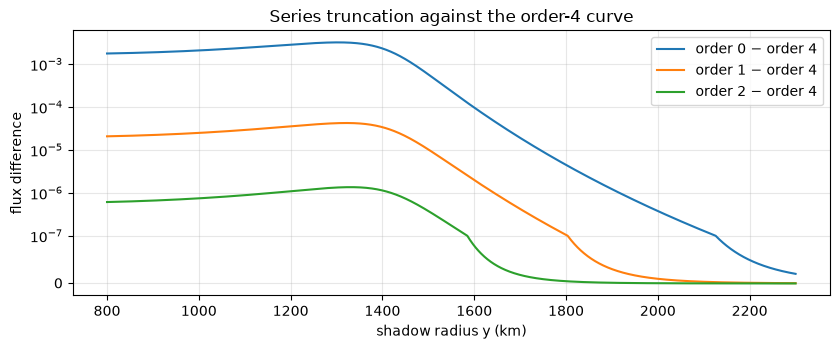

In [5]:
ref4 = EY92.ElliotYoung1992Model(**common, position=y).main()

plt.figure(figsize=(8.5, 3.6))
for order in (0, 1, 2):
    f = EY92.ElliotYoung1992Model(**common, position=y, seriesOrder=order).main()
    plt.plot(y, f - ref4, label=f"order {order} $-$ order 4")
plt.yscale("symlog", linthresh=1e-7)
plt.xlabel("shadow radius y (km)"); plt.ylabel("flux difference")
plt.title("Series truncation against the order-4 curve")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()

kw = dict(position=y, temperatureExponent=-2.0)
steep = {**common, "referenceTemperature": 150.0}
corr = EY92.ElliotYoung1992Model(**steep, **kw).main()
printed = EY92.ElliotYoung1992Model(**steep, **kw, seriesVariant="as-printed").main()
print(f"corrected vs as-printed, order 4, b = -2: "
      f"max |diff| = {np.abs(corr - printed).max():.2e}")

## 4. A haze layer

EY92 Eq. 3.23 adds an absorbing haze below an onset radius $r_1$: absorption coefficient $\kappa_1$ at onset, falling off upward with its own scale height $H_{\tau 1}$. For the rest of this notebook we switch to the Pluto-like transparent case used by the package's two-limb cross-validation ($r_0 = 1250$ km, $\lambda_{g0} = 21$) and drop a haze onset just below half light. The per-ray optical depth and transmission are exposed as `tauObs` and `transmission`. (The helper `EY92.kappa1_from_unit_optical_depth` picks $\kappa_1$ so that $\tau = 1$ at a chosen radius.)

lambda_g0 = 21.00, nu0 = 1.110e-09


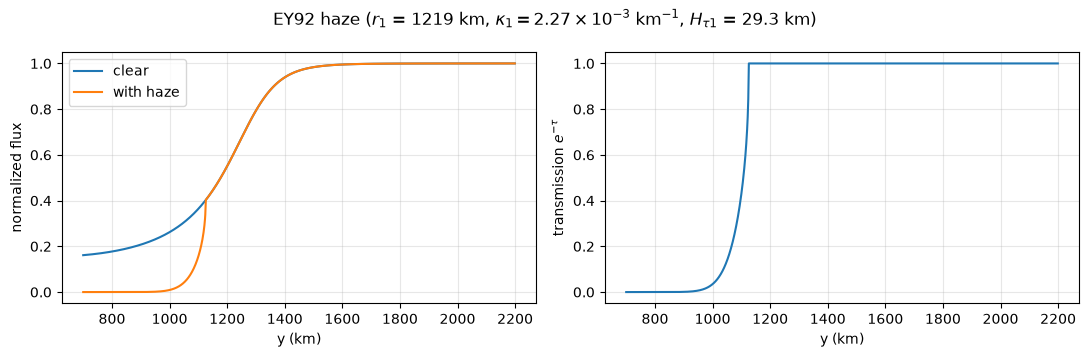

In [6]:
pluto = dict(
    referencePressure=0.1387,    # Pa  -> nu0 = 1.11e-9 at r0 (the cross-validation case)
    referenceTemperature=100.0,  # K
    referenceRadius=1250.0,      # km
    planetMass=1.168e22,         # kg  -> lambda_g0 = 21
    meanMolecularMass=physicalData.MOLAR_MASS["N2"],
    planetDistance=4.323e9,      # km (28.9 AU)
)
y_p = np.arange(700.0, 2200.0, 1.0)

clear = EY92.ElliotYoung1992Model(**pluto, position=y_p)
hazy = EY92.ElliotYoung1992Model(**pluto, position=y_p,
                                 hazeOnsetRadius=1219.0, hazeKappa1=2.27e-3,
                                 hazeScaleHeight=29.3)
f_clear, f_hazy = clear.main(), hazy.main()
print(f"lambda_g0 = {clear.lambda_g0:.2f}, nu0 = {clear.nu0:.3e}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(y_p, f_clear, label="clear")
ax[0].plot(y_p, f_hazy, label="with haze")
ax[0].set_xlabel("y (km)"); ax[0].set_ylabel("normalized flux"); ax[0].legend()
ax[1].plot(y_p, hazy.transmission)
ax[1].set_xlabel("y (km)"); ax[1].set_ylabel(r"transmission $e^{-\tau}$")
for a in ax: a.grid(alpha=0.3)
fig.suptitle(r"EY92 haze ($r_1$ = 1219 km, $\kappa_1 = 2.27\times10^{-3}$ km$^{-1}$, "
             r"$H_{\tau 1}$ = 29.3 km)")
fig.tight_layout()

## 5. Two limbs: the central flash

Near the shadow center, rays refracted **across the axis from the far limb** arrive too, focused by the shadow's cylindrical symmetry into a **central flash** (diverging as $1/\rho$ toward the center). `twoLimb=True` adds this contribution: the far-limb periapsis solves $r + D\theta(r) = -\rho$ — the jleGroup `olcTwoLimb4` construction, cross-validated per limb against CE97 at the $10^{-7}$ level.

**Always pair `twoLimb=True` with `surfaceRadius=`** on small bodies: the analytic atmosphere is transparent all the way down, so without a surface the model happily bends far-limb rays through arbitrarily deep (bright, wrong) layers. A surface blocks every ray whose periapsis lies below it — which also lets the near limb "land": flux → 0 where the star sets behind the hard edge.

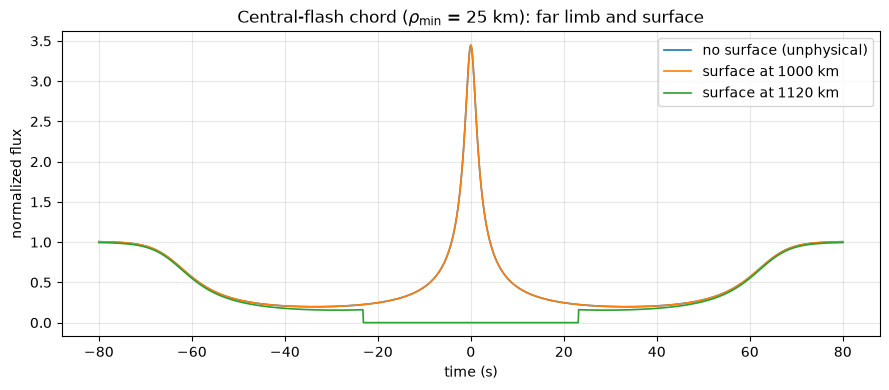

In [7]:
rho_min_c, v_c = 25.0, 20.0
t_c = np.arange(-80.0, 80.001, 0.1)
y_c = np.sqrt(rho_min_c**2 + (v_c * t_c) ** 2)

curves = {}
for r_surf in (None, 1000.0, 1120.0):
    m = EY92.ElliotYoung1992Model(**pluto, position=y_c,
                                  twoLimb=True, surfaceRadius=r_surf)
    curves[r_surf] = (m.main(), m)

plt.figure(figsize=(9, 4))
for r_surf, (f, _) in curves.items():
    label = "no surface (unphysical)" if r_surf is None else f"surface at {r_surf:.0f} km"
    plt.plot(t_c, f, lw=1.2, label=label)
plt.xlabel("time (s)"); plt.ylabel("normalized flux")
plt.title(rf"Central-flash chord ($\rho_{{\rm min}}$ = {rho_min_c:.0f} km): far limb and surface")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()

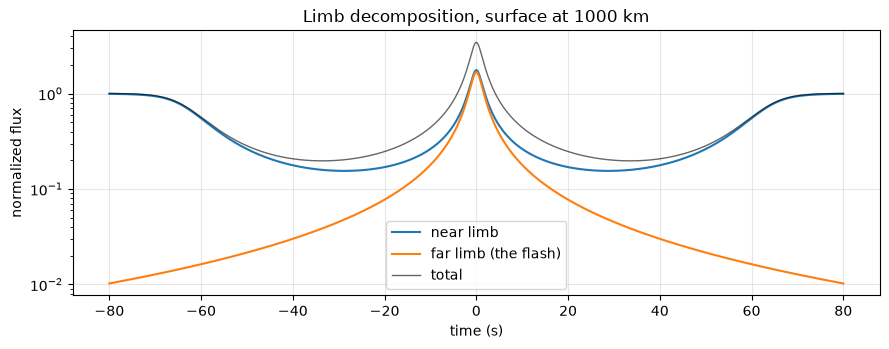

In [8]:
f_flash, m_flash = curves[1000.0]

plt.figure(figsize=(9, 3.6))
plt.semilogy(t_c, m_flash.nearLimbFlux, label="near limb")
plt.semilogy(t_c, m_flash.farLimbFlux, label="far limb (the flash)")
plt.semilogy(t_c, f_flash, "k-", lw=1, alpha=0.6, label="total")
plt.xlabel("time (s)"); plt.ylabel("normalized flux")
plt.title("Limb decomposition, surface at 1000 km")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()

## 6. Gotchas & citation

1. `seriesOrder=4` (default) ≠ Mathematica jleGroup order 1 — match orders when comparing curves.
2. Steep gradients ($b \lesssim -3$) push the series truncation into the $10^{-3}$ regime — cross-check against CE97 (numerical) when it matters.
3. `twoLimb=True` without `surfaceRadius=` passes far-limb rays through arbitrarily deep transparent atmosphere (§5).
4. Evaluation is one-limb-instantaneous per ray: there is no exposure-time binning of the sharp surface/haze cut-on events yet — don't fit real integrated photometry across those edges.
5. The haze path is validated against the EY92 paper's own tables (digitized in `tests/data/ey92-paper/`), a lineage-independent oracle.

**Cite:** Elliot & Young 1992, AJ 103, 991 — and the package (`CITATION.cff`).
Companions: [overview](00_jlegroup_overview.ipynb) · [CE97](02_CE97_basics.ipynb) · [EPQ03](03_EPQ03_basics.ipynb)